# Attention 챗봇 만들기  

학습 목표  

챗봇 훈련 데이터 전처리 과정이 체계적으로 진행되었는가?  

Attention 기반 Transformer 모델을 활용해 챗봇이 실제로 학습되는가?  

챗봇이 사용자의 질문에 그럴듯한 답변을 생성하는가?  

평가 기준  

챗봇 훈련데이터를 위한 전처리와 augmentation이 적절히 수행되어 3만개 가량의 훈련데이터셋이 구축되었다.  

과적합을 피할 수 있는 하이퍼파라미터 셋이 적절히 제시되었다.  

주어진 예문을 포함하여 챗봇에 던진 질문에 적절히 답하는 사례가 제출되었다.  

오늘의 목표: Attention으로 챗봇 만들어보자  

In [1]:
import sys
import subprocess
import importlib.util

# 필요한 패키지가 없으면 자동으로 설치하는 함수
def install_if_missing(package_name, import_name=None):
    # import 이름이 다를 수 있어서 따로 받을 수 있게 한다
    import_name = import_name or package_name

    # 패키지가 없으면 설치한다
    if importlib.util.find_spec(import_name) is None:
        print(f"[INFO] {package_name} 설치 중...")

        subprocess.check_call([
            sys.executable,
            "-m",
            "pip",
            "install",
            package_name,
        ])
    # 이미 있으면 조용히 통과
    else:

        print(f"[INFO] {package_name} 이미 설치됨")


install_if_missing("sentencepiece")
install_if_missing("pandas")
install_if_missing("tqdm")
install_if_missing("matplotlib")

[INFO] sentencepiece 설치 중...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 10.5 MB/s eta 0:00:00a 0:00:01
[INFO] pandas 이미 설치됨
[INFO] tqdm 이미 설치됨
[INFO] matplotlib 이미 설치됨


In [2]:
import os
import re
import math
import random
import urllib.request

from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import sentencepiece as spm
import torch
import torch.nn as nn

from torch.utils.data import Dataset, DataLoader
from tqdm.auto import tqdm

try:
    from IPython.display import display

except Exception:

    def display(x):
        print(x)

# 랜덤 시드, 결과가 매번 너무 춤추지 않게 잡아준다
SEED = 42

# 파이썬, 넘파이, 파이토치 시드를 한 번에 고정하는 함수
def seed_everything(seed=42):

    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

# 랜덤 문어발을 묶어둔다
seed_everything(SEED)

# GPU가 있으면 cuda, 없으면 cpu를 쓴다
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("[INFO] device:", device)
print("[INFO] torch:", torch.__version__)

[INFO] device: cuda
[INFO] torch: 2.7.1+cu118


이것 저것 시도한다고 계속 코드를 수정하다가  

파일이 어딧는지 까먹었다  

찾다가 찾다가 안되면 github 에서 다시 데이터를 받자  

In [3]:
import time

# ChatbotData.csv 후보 경로. 
DATA_CANDIDATES = [
    "./ChatbotData.csv",
    "./data/ChatbotData.csv",
    "../ChatbotData.csv",
    "../data/ChatbotData.csv",
    "/mnt/data/ChatbotData.csv",
    "/aiffel/ChatbotData.csv",
    "/aiffel/data/ChatbotData.csv",
    "/aiffel/aiffel/ChatbotData.csv",
    "/aiffel/aiffel/data/ChatbotData.csv",
    str(Path.home() / "ChatbotData.csv"),
    str(Path.home() / "data/ChatbotData.csv"),
    str(Path.home() / "aiffel/ChatbotData.csv"),
    str(Path.home() / "aiffel/data/ChatbotData.csv"),
    str(Path.home() / "aiffel/transformer_chatbot/ChatbotData.csv"),
    str(Path.home() / "aiffel/transformer_chatbot/data/ChatbotData.csv"),
]

# 로컬에 데이터가 없을 때 받을 주소
DATA_URLS = [
    "https://cdn.jsdelivr.net/gh/songys/Chatbot_data@master/ChatbotData.csv",
    "https://raw.githubusercontent.com/songys/Chatbot_data/master/ChatbotData.csv",
]

# 여러 인코딩으로 CSV 읽기 시도 함수
def read_csv_safely(path):
    # 한국어 CSV에서 자주 만나는 인코딩 후보들
    encodings = ["utf-8-sig", "utf-8", "cp949"]
    # 마지막 에러를 저장
    last_error = None

    # 인코딩 후보를 하나씩 시도
    for enc in encodings:
        try:
            df = pd.read_csv(path, encoding=enc)
            # 성공한 경로와 인코딩을 출력
            print(f"[INFO] CSV 로드 성공: {path}")
            print(f"[INFO] encoding: {enc}")
            # 성공한 DataFrame 반환
            return df
        except Exception as e:
            # 실패 이유는 일단 저장
            last_error = e

    # 모두 실패하면 마지막 에러를 보여준다
    raise last_error

# 후보 경로에서 로컬 데이터를 찾는 함수
def find_local_data():

    for path in DATA_CANDIDATES:
        path = Path(path).expanduser()
        # 파일이 있으면 찾기 성공
        if path.exists():
            print(f"[INFO] 로컬 데이터 발견: {path}")
            return path

    # 후보 경로에 없으면 주변 폴더도 뒤진다
    print("[INFO] 지정 경로에서 찾지 못했습니다. 현재 폴더 아래를 추가 탐색합니다.")

    # 탐색할 루트 폴더들
    search_roots = [
        Path("."),
        Path("./data"),
        Path("/mnt/data"),
    ]

    # 루트 폴더를 하나씩 확인
    for root in search_roots:

        if not root.exists():
            continue

        try:
            # ChatbotData.csv 파일을 재귀 탐색한다
            matches = list(root.rglob("ChatbotData.csv"))
        except Exception:
            # 권한 문제 등이 있으면 빈 리스트 처리
            matches = []

        # 하나라도 찾으면 첫 번째를 사용한다
        if len(matches) > 0:
            print(f"[INFO] 탐색으로 로컬 데이터 발견: {matches[0]}")
            return matches[0]

    # 못 찾으면 None 반환
    return None

# 데이터를 다운로드하는 함수
def download_data(save_path="./ChatbotData.csv"):
    # 저장 경로를 Path 객체로 바꾼다
    save_path = Path(save_path)
    # GitHub가 싫어하지 않게 User-Agent를 넣는다
    headers = {"User-Agent": "Mozilla/5.0"}
    # 실패 이유들을 담아 둔다
    errors = []

    # 다운로드 주소를 순서대로 시도
    for url in DATA_URLS:
        try:
            # 현재 시도 중인 주소를 출력
            print(f"[INFO] 다운로드 시도: {url}")
            # 요청 객체 생성
            request = urllib.request.Request(url, headers=headers)
            # 응답을 받아 파일 내용을 읽는다
            with urllib.request.urlopen(request, timeout=30) as response:
                content = response.read()
            # 파일로 저장
            with open(save_path, "wb") as f:
                f.write(content)
            # 다운로드 성공 알림
            print(f"[INFO] 다운로드 완료: {save_path}")
            return save_path
        except Exception as e:
            # 실패해도 다음 주소를 시도
            print(f"[WARN] 다운로드 실패: {url}")
            print(f"[WARN] 원인: {e}")
            errors.append(str(e))

    # 모든 다운로드가 실패하면 친절하게 멈춘다
    raise FileNotFoundError(
        "\n[ERROR] ChatbotData.csv를 찾을 수 없고 자동 다운로드도 실패했습니다.\n\n"
        "해결 방법:\n"
        "1. ChatbotData.csv 파일을 직접 다운로드합니다.\n"
        "2. 현재 노트북과 같은 폴더에 업로드합니다.\n"
        "3. 이 셀을 다시 실행합니다.\n\n"
        "필요 컬럼: Q, A, label은 선택\n\n"
        "다운로드 실패 원인 목록:\n" + "\n".join(errors)
    )

# 로컬에서 찾고, 없으면 다운로드까지 시도하는 함수
def find_or_download_data():
    # 먼저 로컬 파일을 찾는다
    local_path = find_local_data()
    # 찾으면 바로 사용한다
    if local_path is not None:
        return local_path
    # 없으면 다운로드로 넘어간다
    print("[INFO] 로컬 데이터가 없어 자동 다운로드를 시도합니다.")
    return download_data("./ChatbotData.csv")

# 데이터 파일 경로를 확보
data_path = find_or_download_data()
# CSV를 안전하게 읽는다
raw_df = read_csv_safely(data_path)

# 컬럼명 앞뒤 공백을 제거
raw_df.columns = [str(col).strip() for col in raw_df.columns]

# 원본 데이터 모양을 확인
print("[INFO] raw shape:", raw_df.shape)
print("[INFO] columns:", raw_df.columns.tolist())
# 맨 위 몇 줄을 눈으로 확인
display(raw_df.head())

# 꼭 필요한 컬럼 이름
required_cols = {"Q", "A"}
# Q, A가 없으면 여기서 알려준다
if not required_cols.issubset(set(raw_df.columns)):
    raise ValueError(
        "[ERROR] 데이터에 Q, A 컬럼이 필요합니다.\n"
        f"현재 컬럼: {raw_df.columns.tolist()}"
    )

# label이 없으면 기본값 0을 넣는다
if "label" not in raw_df.columns:
    print("[WARN] label 컬럼이 없어 0으로 생성합니다.")
    raw_df["label"] = 0

# 데이터 로드 완료 알림
print("[INFO] 데이터 로드 완료")
print(raw_df[["Q", "A", "label"]].head())

[INFO] 로컬 데이터 발견: /home/jovyan/data/ChatbotData.csv
[INFO] CSV 로드 성공: /home/jovyan/data/ChatbotData.csv
[INFO] encoding: utf-8-sig
[INFO] raw shape: (11823, 3)
[INFO] columns: ['Q', 'A', 'label']


,Q,A,label
0,12시 땡!,하루가 또 가네요.,0
1,1지망 학교 떨어졌어,위로해 드립니다.,0
2,3박4일 놀러가고 싶다,여행은 언제나 좋죠.,0
3,3박4일 정도 놀러가고 싶다,여행은 언제나 좋죠.,0
4,PPL 심하네,눈살이 찌푸려지죠.,0


[INFO] 데이터 로드 완료
                 Q            A  label
0           12시 땡!   하루가 또 가네요.      0
1      1지망 학교 떨어졌어    위로해 드립니다.      0
2     3박4일 놀러가고 싶다  여행은 언제나 좋죠.      0
3  3박4일 정도 놀러가고 싶다  여행은 언제나 좋죠.      0
4          PPL 심하네   눈살이 찌푸려지죠.      0


In [4]:
# 질문/답변 컬럼 이름을 Q/A로 통일하는 함수
def standardize_columns(df):
    # 원본을 건드리지 않기 위해 복사
    df = df.copy()
    # 소문자 컬럼명에서 원래 컬럼명으로 가는 지도
    lower_map = {str(c).lower().strip(): c for c in df.columns}

    # 질문 컬럼 후보들
    q_candidates = ["q", "question", "questions", "질문", "input", "source"]
    # 답변 컬럼 후보들
    a_candidates = ["a", "answer", "answers", "답변", "response", "target"]

    # 찾은 질문 컬럼명
    q_col = None
    # 찾은 답변 컬럼명
    a_col = None

    # 질문 컬럼을 찾는다
    for key in q_candidates:
        if key in lower_map:
            q_col = lower_map[key]
            break

    # 답변 컬럼을 찾는다
    for key in a_candidates:
        if key in lower_map:
            a_col = lower_map[key]
            break

    # 둘 중 하나라도 없으면 멈춘다
    if q_col is None or a_col is None:
        raise ValueError(
            "질문/답변 컬럼을 찾지 못했습니다. "
            "CSV 컬럼명을 Q, A로 맞추거나 standardize_columns()에서 직접 지정하세요. "
            f"현재 컬럼: {list(df.columns)}"
        )

    # 표준 컬럼만 담은 새 DataFrame 생성
    out = pd.DataFrame()
    # 질문을 문자열로 저장
    out["Q"] = df[q_col].astype(str)
    # 답변도 문자열로 저장
    out["A"] = df[a_col].astype(str)

    # label이 있으면 가져온다
    if "label" in lower_map:
        out["label"] = df[lower_map["label"]]
    # 없으면 기본값을 넣는다
    else:
        out["label"] = -1

    # 정리된 DataFrame 반환
    return out

# 컬럼 이름을 표준화
df = standardize_columns(raw_df)
# 표준화 결과를 확인
display(df.head())
print("[INFO] standardized shape:", df.shape)

,Q,A,label
0,12시 땡!,하루가 또 가네요.,0
1,1지망 학교 떨어졌어,위로해 드립니다.,0
2,3박4일 놀러가고 싶다,여행은 언제나 좋죠.,0
3,3박4일 정도 놀러가고 싶다,여행은 언제나 좋죠.,0
4,PPL 심하네,눈살이 찌푸려지죠.,0


[INFO] standardized shape: (11823, 3)


문장 전처리를 하자  

질문 답변을 모델이 학습하기 좋은 형태로 정리한다  

In [5]:
# 데이터 전처리 함수
def preprocess_sentence(sentence):
    # 어떤 값이 와도 문자열로 바꾼다
    sentence = str(sentence)
    # HTML 태그 제거
    sentence = re.sub(r"<[^>]+>", " ", sentence)
    # URL 제거
    sentence = re.sub(r"http\S+|www\.\S+", " ", sentence)
    # 숨어 있는 특수 공백 정리
    sentence = sentence.replace("\u200b", " ").replace("\xa0", " ")
    # 한글, 영어, 숫자, 기본 문장부호만 남긴다
    sentence = re.sub(r"[^가-힣a-zA-Z0-9?.!,~'\s]", " ", sentence)
    # 문장부호가 너무 많이 반복되면 살짝 진정시킨다
    sentence = re.sub(r"([?.!,~])\1{2,}", r"\1\1", sentence)
    # 문장부호 앞 공백을 정리한다
    sentence = re.sub(r"\s+([?.!,~])", r"\1", sentence)
    # 문장부호 양옆에 공백을 둔다
    sentence = re.sub(r"([?.!,~])", r" \1 ", sentence)
    # 여러 칸 공백을 한 칸으로 줄인다
    sentence = re.sub(r"\s+", " ", sentence).strip()
    # 깨끗한 문장 반환
    return sentence

# 데이터프레임 정제, 필터링 함수
def clean_chatbot_dataframe(df, min_len=2, max_len=80):
    # 원본 보존용 복사
    clean = df.copy()
    # 질문 전처리
    clean["Q"] = clean["Q"].map(preprocess_sentence)
    # 답변 전처리
    clean["A"] = clean["A"].map(preprocess_sentence)
    # 빈 값 제거
    clean = clean.dropna(subset=["Q", "A"])
    # 너무 짧거나 긴 질문 제거
    clean = clean[(clean["Q"].str.len() >= min_len) & (clean["Q"].str.len() <= max_len)]
    # 너무 짧거나 긴 답변 제거
    clean = clean[(clean["A"].str.len() >= min_len) & (clean["A"].str.len() <= max_len)]
    # 완전 중복 질문 답변 제거
    clean = clean.drop_duplicates(subset=["Q", "A"]).reset_index(drop=True)
    # 인덱스 정리 후 반환
    return clean

# 데이터 정제 실행
clean_df = clean_chatbot_dataframe(df)
# 정제 결과 출력
print("[INFO] cleaned shape:", clean_df.shape)
# 질문 길이 요약
print("[INFO] Q length mean:", round(clean_df["Q"].str.len().mean(), 2))
# 답변 길이 요약
print("[INFO] A length mean:", round(clean_df["A"].str.len().mean(), 2))
# 정제된 데이터 샘플 확인
display(clean_df.head(10))

[INFO] cleaned shape: (11739, 3)
[INFO] Q length mean: 13.24
[INFO] A length mean: 16.05


,Q,A,label
0,12시 땡 !,하루가 또 가네요 .,0
1,1지망 학교 떨어졌어,위로해 드립니다 .,0
2,3박4일 놀러가고 싶다,여행은 언제나 좋죠 .,0
3,3박4일 정도 놀러가고 싶다,여행은 언제나 좋죠 .,0
4,PPL 심하네,눈살이 찌푸려지죠 .,0
5,SD카드 망가졌어,다시 새로 사는 게 마음 편해요 .,0
6,SD카드 안돼,다시 새로 사는 게 마음 편해요 .,0
7,SNS 맞팔 왜 안하지,잘 모르고 있을 수도 있어요 .,0
8,SNS 시간낭비인 거 아는데 매일 하는 중,시간을 정하고 해보세요 .,0
9,SNS 시간낭비인데 자꾸 보게됨,시간을 정하고 해보세요 .,0


3만개 학습 데이터 갯수를 맞추기 위해 데이터를 증강한다  

train 데이터만 증강하고 validation 데이터는 원본 그대로 유지한다  

In [6]:
# 증강 후 만들고 싶은 학습 데이터 개수
TARGET_SIZE = 30000

# 질문에만 살짝 적용할 동의어 규칙
QUESTION_SYNONYM_RULES = [
    ("안녕", "하이"),
    ("고마워", "감사해"),
    ("미안", "죄송"),
    ("어떻게", "어케"),
    ("뭐해", "뭐 하고 있어"),
    ("뭐야", "무엇이야"),
    ("추천", "알려줘"),
    ("좋아", "괜찮아"),
    ("힘들어", "지쳐"),
    ("슬퍼", "우울해"),
    ("기뻐", "좋아"),
    ("사랑", "좋아하는 마음"),
    ("친구", "지인"),
]

# 문장부호 주변 공백을 다시 정리하는 함수
def compact_punctuation(text):
    # 문장부호 앞 공백 제거
    text = re.sub(r"\s+([?.!,~])", r"\1", str(text))
    # 문장부호 뒤 공백 정리
    text = re.sub(r"([?.!,~])", r" \1 ", text)
    # 다중 공백 제거
    text = re.sub(r"\s+", " ", text).strip()
    # 정리된 문장 반환
    return text

# 문장 속 동의어 하나를 바꾸는 함수
def replace_one_synonym(text, mode):
    # 바꿀 수 있는 후보를 모은다
    candidates = [(a, b) for a, b in QUESTION_SYNONYM_RULES if a in text]
    # 후보가 없으면 원문 그대로 반환
    if not candidates:
        return text
    # mode에 따라 후보를 하나 고른다
    src, dst = candidates[mode % len(candidates)]
    # 딱 한 번만 바꾼다
    return text.replace(src, dst, 1)

# 질문 문장을 의미 보존 방식으로 증강하는 함수
def augment_question(question, mode):
    # 문자열로 만들고 앞뒤 공백 제거
    q = str(question).strip()

    # 0번은 원문 그대로
    if mode == 0:
        new_q = q
    # 끝 문장부호를 빼본다
    elif mode == 1:
        new_q = re.sub(r"\s*[?.!,~]+\s*$", "", q)
    # 물음표를 붙여 질문 느낌을 더한다
    elif mode == 2:
        new_q = re.sub(r"\s*[?.!,~]+\s*$", "", q) + " ?"
    # 부드러운 시작어를 붙인다
    elif mode == 3:
        new_q = "음 " + q
    # 동의어 하나를 바꾼다
    elif mode == 4:
        new_q = replace_one_synonym(q, mode)
    # 마지막은 원문 꼬리 정리 버전
    else:
        new_q = q.replace(" .", ".").replace(" ?", "?")

    # 문장부호 정리 후 반환
    return compact_punctuation(new_q)

# 학습 데이터 증강 함수
def build_augmented_dataset(base_df, target_size=30000, seed=42):
    # 랜덤 생성기 준비
    rng = random.Random(seed)
    # 원본을 섞어서 시작한다
    base_df = base_df.sample(frac=1, random_state=seed).reset_index(drop=True)
    # 결과 행들을 담을 리스트
    rows = []
    # 증강 모드 개수
    num_modes = 6

    # 목표 개수까지 돌린다
    while len(rows) < target_size:
        # 원본 데이터를 한 바퀴 순회한다
        for i, row in base_df.iterrows():
            # 목표를 채우면 멈춘다
            if len(rows) >= target_size:
                break
            # 행 순서와 랜덤을 섞어 증강 모드를 고른다
            mode = (len(rows) + rng.randint(0, 1000)) % num_modes
            # 질문만 증강
            new_q = augment_question(row["Q"], mode)
            # 답변은 정답 보존을 위해 그대로 둔다
            new_a = row["A"]
            # 새 행을 저장
            rows.append({
                "Q": new_q,
                "A": new_a,
                "label": row.get("label", -1),
                "augmentation_type": f"mode_{mode}",
            })

    # 리스트를 DataFrame으로 바꾼다
    aug_df = pd.DataFrame(rows)
    # 중복이 너무 많아도 학습은 되지만, 섞어서 편향을 줄인다
    aug_df = aug_df.sample(frac=1, random_state=seed).reset_index(drop=True)
    # 증강 데이터 반환
    return aug_df

In [7]:
# 검증 데이터 비율
VALID_RATIO = 0.1

# 정제 데이터를 먼저 섞는다
base_df = clean_df.sample(frac=1, random_state=SEED).reset_index(drop=True)
# 검증 데이터 개수 계산
valid_size = int(len(base_df) * VALID_RATIO)

# 검증 데이터는 앞쪽 일부를 사용
valid_df = base_df.iloc[:valid_size].copy().reset_index(drop=True)
# 학습 원본 데이터는 나머지를 사용
train_base_df = base_df.iloc[valid_size:].copy().reset_index(drop=True)

# 학습 데이터만 증강한다. valid에 증강 금지, 시험지는 깨끗해야 한다
train_df = build_augmented_dataset(train_base_df, target_size=TARGET_SIZE, seed=SEED)

# 검증 데이터는 필요한 컬럼만 남긴다
valid_df = valid_df[["Q", "A", "label"]].reset_index(drop=True)

# 전처리와 증강 결과를 출력
print("[INFO] clean rows             :", len(clean_df))
print("[INFO] train base rows        :", len(train_base_df))
print("[INFO] augmented train rows   :", len(train_df))
print("[INFO] valid rows, no augment :", len(valid_df))
print("[INFO] augmentation type counts")
# 증강 모드별 개수 확인
display(train_df["augmentation_type"].value_counts().to_frame("count"))
# 학습 데이터 샘플 확인
display(train_df.head(10))

[INFO] clean rows             : 11739
[INFO] train base rows        : 10566
[INFO] augmented train rows   : 30000
[INFO] valid rows, no augment : 1173
[INFO] augmentation type counts


,count
augmentation_type,
mode_3,5051
mode_1,5027
mode_4,5018
mode_2,5007
mode_0,4995
mode_5,4902


,Q,A,label,augmentation_type
0,항상 내편이 생겨서 좋아,내 편이 생긴다는 자체가 행복하죠 .,2,mode_1
1,쇼핑 중독인가봐,마음이 헛헛한가봐요 .,0,mode_0
2,매일 아침 피곤해,좀 더 일찍 잠자리에 들어보세요 .,0,mode_4
3,음 걔 앞에만 서면 말이 안 나와,무슨 말을 할지 연습해보세요 .,2,mode_3
4,비는정말싫다,날씨에 따라 감정도 변하죠 .,1,mode_1
5,음 잘못한 거도 없는데 찔려,저도 가끔 그래요 .,0,mode_3
6,음 폰 베터리가 없네,어서 충전 하세요 .,0,mode_3
7,내일 모의평가다,공부한 만큼 나올 거예요 .,0,mode_0
8,음 너무 마른 거 같아,적당해요 .,0,mode_3
9,너무 기대했나봐,아무것도 바라지 않을 때 천하를 얻는다는 말이 있어요 .,0,mode_1


이제 SentencePiece로 한국어 문장을 토큰화한다.  

In [8]:
# SentencePiece 모델 이름
SPM_PREFIX = "chatbot_spm"
# SentencePiece 학습용 말뭉치 파일
SPM_INPUT = "chatbot_corpus.txt"

# 토크나이저가 사용할 최대 단어 조각 개수
VOCAB_SIZE = 8000

# 패딩 토큰 번호
PAD_ID = 0
# 문장 시작 토큰 번호
BOS_ID = 1
# 문장 끝 토큰 번호
EOS_ID = 2
# 모르는 단어 토큰 번호
UNK_ID = 3

# 질문과 답변을 한 줄씩 말뭉치 파일에 저장
with open(SPM_INPUT, "w", encoding="utf-8") as f:
    # 학습 데이터의 질문 답변을 모두 기록
    for q, a in zip(train_df["Q"], train_df["A"]):
        f.write(str(q) + "\n")
        f.write(str(a) + "\n")

# SentencePiece 토크나이저 학습 시작
spm.SentencePieceTrainer.Train(
    # 학습 말뭉치 경로
    input=SPM_INPUT,
    # 저장될 모델 접두사
    model_prefix=SPM_PREFIX,
    # vocab 크기
    vocab_size=VOCAB_SIZE,
    # 특수 토큰 번호 지정
    pad_id=PAD_ID,
    bos_id=BOS_ID,
    eos_id=EOS_ID,
    unk_id=UNK_ID,
    # 한국어 문자 보존 비율
    character_coverage=0.9995,
    # BPE 방식 사용
    model_type="bpe",
    # 데이터가 작아도 실패하지 않게 한다
    hard_vocab_limit=False,
)

# 학습된 토크나이저 객체 생성
tokenizer = spm.SentencePieceProcessor()
# 모델 파일 로드
tokenizer.load(f"{SPM_PREFIX}.model")

# 토크나이저 결과 확인
print("[INFO] vocab size:", tokenizer.get_piece_size())
print("[TEST pieces]", tokenizer.encode("오늘 너무 힘들어", out_type=str))
print("[TEST ids]", tokenizer.encode("오늘 너무 힘들어", out_type=int))

[INFO] vocab size: 8000
[TEST pieces] ['▁오늘', '▁너무', '▁힘들어']
[TEST ids] [135, 58, 486]


sentencepiece_trainer.cc(78) LOG(INFO) Starts training with : 
trainer_spec {
  input: chatbot_corpus.txt
  input_format: 
  model_prefix: chatbot_spm
  model_type: BPE
  vocab_size: 8000
  self_test_sample_size: 0
  character_coverage: 0.9995
  input_sentence_size: 0
  shuffle_input_sentence: 1
  seed_sentencepiece_size: 1000000
  shrinking_factor: 0.75
  max_sentence_length: 4192
  num_threads: 16
  num_sub_iterations: 2
  max_sentencepiece_length: 16
  split_by_unicode_script: 1
  split_by_number: 1
  split_by_whitespace: 1
  split_digits: 0
  pretokenization_delimiter: 
  treat_whitespace_as_suffix: 0
  allow_whitespace_only_pieces: 0
  required_chars: 
  byte_fallback: 0
  vocabulary_output_piece_score: 1
  train_extremely_large_corpus: 0
  seed_sentencepieces_file: 
  hard_vocab_limit: 0
  use_all_vocab: 0
  unk_id: 3
  bos_id: 1
  eos_id: 2
  pad_id: 0
  unk_piece: <unk>
  bos_piece: <s>
  eos_piece: </s>
  pad_piece: <pad>
  unk_surface:  ⁇ 
  enable_differential_privacy: 0
  d

토큰화가 잘 되었는지 안되었는지 모르겠다  

오류 안떳으니까 다음으로 넘어가자  

Dataset과 DataLoader 구성한다  

In [9]:
# 질문 답변 최대 토큰 길이
MAX_LEN = 40
# 한 번에 학습할 문장 쌍 개수
BATCH_SIZE = 64

# 문장을 토큰 번호로 바꾸는 함수
def encode_sentence(sentence, max_len=MAX_LEN):
    # SentencePiece로 문장을 숫자 토큰으로 바꾼다
    ids = tokenizer.encode(str(sentence), out_type=int)
    # 앞에는 BOS, 뒤에는 EOS를 붙인다
    ids = [BOS_ID] + ids[:max_len - 2] + [EOS_ID]
    # 토큰 리스트 반환
    return ids

# 토큰 목록 길이를 MAX_LEN에 맞추는 함수
def pad_to_len(ids, max_len=MAX_LEN, pad_id=PAD_ID):
    # 길이가 충분하면 잘라낸다
    if len(ids) >= max_len:
        return ids[:max_len]
    # 짧으면 PAD를 채운다
    return ids + [pad_id] * (max_len - len(ids))

# 챗봇 데이터셋 클래스 정의
class ChatbotDataset(Dataset):
    # DataFrame을 받아 질문과 답변을 보관
    def __init__(self, dataframe):
        # 질문 리스트
        self.questions = dataframe["Q"].tolist()
        # 답변 리스트
        self.answers = dataframe["A"].tolist()

    # 데이터 개수를 알려준다
    def __len__(self):
        return len(self.questions)

    # idx번째 질문 답변을 텐서로 반환
    def __getitem__(self, idx):
        # 질문 인코딩과 패딩
        src = pad_to_len(encode_sentence(self.questions[idx]))
        # 답변 인코딩과 패딩
        tgt = pad_to_len(encode_sentence(self.answers[idx]))
        # 모델이 먹을 딕셔너리 반환
        return {
            "src": torch.tensor(src, dtype=torch.long),
            "tgt": torch.tensor(tgt, dtype=torch.long),
        }

# 학습 데이터셋 생성
train_dataset = ChatbotDataset(train_df)
# 검증 데이터셋 생성
valid_dataset = ChatbotDataset(valid_df)

# GPU일 때만 pin_memory를 켠다
PIN_MEMORY = device.type == "cuda"

# 학습 데이터 로더
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=PIN_MEMORY,
)

# 검증 데이터 로더
valid_loader = DataLoader(
    valid_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=PIN_MEMORY,
)

# 배치 하나를 확인
batch = next(iter(train_loader))
print("[INFO] src shape:", batch["src"].shape)
print("[INFO] tgt shape:", batch["tgt"].shape)

[INFO] src shape: torch.Size([64, 40])
[INFO] tgt shape: torch.Size([64, 40])


PositionalEncoding 클래스 생성  

mask 생성  

모델 생성  

In [10]:
# 위치 정보를 더하는 클래스 정의
class PositionalEncoding(nn.Module):
    # d_model 차원의 위치 벡터를 미리 만든다
    def __init__(self, d_model, max_len=5000, dropout=0.1):
        # 부모 클래스 초기화
        super().__init__()
        # 살짝 랜덤하게 꺼서 과적합을 줄인다
        self.dropout = nn.Dropout(dropout)

        # 위치 인코딩을 담을 빈 행렬
        pe = torch.zeros(max_len, d_model)
        # 0부터 max_len까지 위치 번호
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        # sin, cos 주파수 계산
        div_term = torch.exp(
            torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model)
        )

        # 짝수 차원에는 sin
        pe[:, 0::2] = torch.sin(position * div_term)
        # 홀수 차원에는 cos
        pe[:, 1::2] = torch.cos(position * div_term)
        # 배치 차원을 하나 붙인다
        pe = pe.unsqueeze(0)

        # 학습 파라미터는 아니지만 모델과 함께 저장되게 한다
        self.register_buffer("pe", pe)

    # 입력 임베딩에 위치 정보를 더한다
    def forward(self, x):
        # 현재 문장 길이만큼 위치 벡터를 더한다
        x = x + self.pe[:, :x.size(1)]
        # dropout 적용 후 반환
        return self.dropout(x)

# 미래 토큰을 못 보게 하는 마스크 생성 함수
def make_tgt_subsequent_mask(tgt_len, device):
    # 위쪽 삼각형은 미래 위치라서 막는다
    mask = torch.triu(
        torch.ones(tgt_len, tgt_len, device=device, dtype=torch.bool),
        diagonal=1,
    )
    # True인 곳은 Attention이 보지 못한다
    return mask

# Attention 기반 Transformer 챗봇 모델
class AttentionChatbotTransformer(nn.Module):
    # Transformer 내부에 Multi-Head Attention이 들어 있다. 오늘의 주인공!
    def __init__(
        self,
        vocab_size,
        d_model=256,
        nhead=8,
        num_encoder_layers=2,
        num_decoder_layers=2,
        dim_feedforward=1024,
        dropout=0.2,
        max_len=128,
        pad_id=0,
    ):
        # 부모 클래스 초기화
        super().__init__()
        # pad 토큰 번호 저장
        self.pad_id = pad_id
        # 임베딩 차원 저장
        self.d_model = d_model

        # 질문 토큰 임베딩
        self.src_embedding = nn.Embedding(vocab_size, d_model, padding_idx=pad_id)
        # 답변 토큰 임베딩
        self.tgt_embedding = nn.Embedding(vocab_size, d_model, padding_idx=pad_id)
        # 질문 위치 인코딩
        self.src_positional_encoding = PositionalEncoding(d_model, max_len=max_len, dropout=dropout)
        # 답변 위치 인코딩
        self.tgt_positional_encoding = PositionalEncoding(d_model, max_len=max_len, dropout=dropout)

        # PyTorch Transformer, 내부에서 Attention이 열심히 질문과 답변을 본다
        self.transformer = nn.Transformer(
            d_model=d_model,
            nhead=nhead,
            num_encoder_layers=num_encoder_layers,
            num_decoder_layers=num_decoder_layers,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True,
        )

        # Transformer 출력 벡터를 vocab 점수로 바꾼다
        self.generator = nn.Linear(d_model, vocab_size)

    # 모델이 한 번 앞으로 계산하는 함수
    def forward(self, src, tgt):
        # 질문의 PAD 위치 마스크
        src_key_padding_mask = src.eq(self.pad_id)
        # 답변의 PAD 위치 마스크
        tgt_key_padding_mask = tgt.eq(self.pad_id)
        # 답변이 미래 토큰을 보지 못하게 하는 마스크
        tgt_mask = make_tgt_subsequent_mask(tgt.size(1), tgt.device)

        # 질문 토큰을 임베딩하고 스케일을 맞춘다
        src_emb = self.src_embedding(src) * math.sqrt(self.d_model)
        # 답변 토큰도 임베딩하고 스케일을 맞춘다
        tgt_emb = self.tgt_embedding(tgt) * math.sqrt(self.d_model)
        # 질문 위치 정보를 더한다
        src_emb = self.src_positional_encoding(src_emb)
        # 답변 위치 정보를 더한다
        tgt_emb = self.tgt_positional_encoding(tgt_emb)

        # Transformer로 인코더 디코더 Attention 계산
        output = self.transformer(
            src=src_emb,
            tgt=tgt_emb,
            tgt_mask=tgt_mask,
            src_key_padding_mask=src_key_padding_mask,
            tgt_key_padding_mask=tgt_key_padding_mask,
            memory_key_padding_mask=src_key_padding_mask,
        )
        # vocab 점수로 변환해서 반환
        return self.generator(output)

하이퍼 파라미터 설정  

모델에 값 전달해주고 학습 스탠바이  

In [11]:
# 하이퍼파라미터 모음
HYPERPARAMS = {
    # vocab 크기
    "vocab_size": tokenizer.get_piece_size(),
    # 최대 토큰 길이
    "max_len": MAX_LEN,
    # 배치 크기
    "batch_size": BATCH_SIZE,
    # 임베딩 차원, 처음 돌리기 좋게 너무 크지 않게 잡았다
    "d_model": 128,
    # Multi-Head Attention 머리 수
    "nhead": 4,
    # 인코더 층 수
    "num_encoder_layers": 2,
    # 디코더 층 수
    "num_decoder_layers": 2,
    # feedforward 내부 차원
    "dim_feedforward": 512,
    # dropout, 과적합 방지용 작은 우산
    "dropout": 0.2,
    # 학습률
    "learning_rate": 3e-4,
    # weight decay, 가중치 다이어트
    "weight_decay": 1e-4,
    # label smoothing, 정답을 너무 딱딱하게 믿지 않기
    "label_smoothing": 0.1,
    # gradient clipping 한계값
    "grad_clip_norm": 1.0,
    # 최대 epoch 수, Early Stopping이 먼저 끊을 수 있다
    "epochs": 30,
    # 성능이 안 좋아질 때 기다리는 횟수
    "early_stopping_patience": 6,
    # 개선으로 인정할 최소 차이
    "min_delta": 1e-3,
}

# 하이퍼파라미터 출력
for k, v in HYPERPARAMS.items():
    print(f"{k:25s}: {v}")

# 모델 생성
model = AttentionChatbotTransformer(
    vocab_size=HYPERPARAMS["vocab_size"],
    d_model=HYPERPARAMS["d_model"],
    nhead=HYPERPARAMS["nhead"],
    num_encoder_layers=HYPERPARAMS["num_encoder_layers"],
    num_decoder_layers=HYPERPARAMS["num_decoder_layers"],
    dim_feedforward=HYPERPARAMS["dim_feedforward"],
    dropout=HYPERPARAMS["dropout"],
    max_len=MAX_LEN + 5,
    pad_id=PAD_ID,
).to(device)

# 손실 함수 생성, PAD는 무시
criterion = nn.CrossEntropyLoss(
    ignore_index=PAD_ID,
    label_smoothing=HYPERPARAMS["label_smoothing"],
)

# AdamW 옵티마이저 생성
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=HYPERPARAMS["learning_rate"],
    betas=(0.9, 0.98),
    eps=1e-9,
    weight_decay=HYPERPARAMS["weight_decay"],
)

# valid loss가 멈추면 학습률을 줄인다
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=2,
)

# 학습 가능한 파라미터 수 확인
num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"[INFO] trainable parameters: {num_params:,}")

vocab_size               : 8000
max_len                  : 40
batch_size               : 64
d_model                  : 128
nhead                    : 4
num_encoder_layers       : 2
num_decoder_layers       : 2
dim_feedforward          : 512
dropout                  : 0.2
learning_rate            : 0.0003
weight_decay             : 0.0001
label_smoothing          : 0.1
grad_clip_norm           : 1.0
epochs                   : 30
early_stopping_patience  : 6
min_delta                : 0.001
[INFO] trainable parameters: 4,006,208


이제 학습해보자.  

30 epoch까지 열어두지만, Early Stopping이 과적합 냄새를 맡으면 먼저 멈춘다.  

In [12]:
# best 모델 저장 경로
SAVE_PATH = "best_attention_chatbot.pt"

# 한 epoch 동안 학습하는 함수
def train_one_epoch(model, loader):
    # 모델을 학습 모드로 바꾼다
    model.train()
    # 누적 손실
    total_loss = 0.0
    # PAD가 아닌 토큰 수
    total_tokens = 0

    # 진행바 준비
    progress = tqdm(loader, desc="train", leave=False)

    # 배치를 하나씩 꺼낸다
    for batch in progress:
        # 질문을 장치로 보낸다
        src = batch["src"].to(device)
        # 답변을 장치로 보낸다
        tgt = batch["tgt"].to(device)

        # 디코더 입력은 EOS 전까지
        tgt_input = tgt[:, :-1]
        # 정답은 BOS 다음부터
        tgt_output = tgt[:, 1:]

        # 이전 gradient를 지운다
        optimizer.zero_grad(set_to_none=True)
        # 모델 예측 실행
        logits = model(src, tgt_input)
        # loss 계산
        loss = criterion(
            logits.reshape(-1, logits.size(-1)),
            tgt_output.reshape(-1),
        )
        # 역전파로 gradient 계산
        loss.backward()
        # gradient 폭주 방지
        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            HYPERPARAMS["grad_clip_norm"],
        )
        # 파라미터 업데이트
        optimizer.step()

        # PAD가 아닌 토큰 수 계산
        non_pad = tgt_output.ne(PAD_ID).sum().item()
        # loss 누적
        total_loss += loss.item() * non_pad
        # 토큰 수 누적
        total_tokens += non_pad
        # 진행바에 현재 loss 표시
        progress.set_postfix(loss=f"{loss.item():.4f}")

    # 토큰 기준 평균 loss 반환
    return total_loss / max(total_tokens, 1)

# gradient 계산 없이 검증하는 함수
@torch.no_grad()
def evaluate(model, loader):
    # 모델을 평가 모드로 바꾼다
    model.eval()
    # 누적 손실
    total_loss = 0.0
    # PAD가 아닌 토큰 수
    total_tokens = 0

    # 검증 배치를 하나씩 본다
    for batch in tqdm(loader, desc="valid", leave=False):
        # 질문을 장치로 보낸다
        src = batch["src"].to(device)
        # 답변을 장치로 보낸다
        tgt = batch["tgt"].to(device)
        # 디코더 입력
        tgt_input = tgt[:, :-1]
        # 정답 토큰
        tgt_output = tgt[:, 1:]
        # 모델 예측
        logits = model(src, tgt_input)
        # loss 계산
        loss = criterion(
            logits.reshape(-1, logits.size(-1)),
            tgt_output.reshape(-1),
        )

        # PAD가 아닌 토큰 수
        non_pad = tgt_output.ne(PAD_ID).sum().item()
        # loss 누적
        total_loss += loss.item() * non_pad
        # 토큰 수 누적
        total_tokens += non_pad

    # 평균 검증 loss 반환
    return total_loss / max(total_tokens, 1)

# 학습 기록 저장용 딕셔너리
history = {
    "epoch": [],
    "train_loss": [],
    "valid_loss": [],
    "lr": [],
}

# 가장 좋은 valid loss
best_valid_loss = float("inf")
# 개선이 없는 epoch 수
bad_epochs = 0

# epoch 반복 시작
for epoch in range(1, HYPERPARAMS["epochs"] + 1):
    # 학습 loss 계산
    train_loss = train_one_epoch(model, train_loader)
    # 검증 loss 계산
    valid_loss = evaluate(model, valid_loader)
    # 스케줄러에 valid loss 전달
    scheduler.step(valid_loss)
    # 현재 학습률 확인
    current_lr = optimizer.param_groups[0]["lr"]

    # 기록 저장
    history["epoch"].append(epoch)
    history["train_loss"].append(train_loss)
    history["valid_loss"].append(valid_loss)
    history["lr"].append(current_lr)

    # valid loss가 좋아졌는지 확인
    improved = valid_loss < best_valid_loss - HYPERPARAMS["min_delta"]

    # 좋아졌으면 모델 저장
    if improved:
        # best 갱신
        best_valid_loss = valid_loss
        # bad epoch 초기화
        bad_epochs = 0
        # 체크포인트 저장
        torch.save(
            {
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "hyperparams": HYPERPARAMS,
                "best_valid_loss": best_valid_loss,
                "epoch": epoch,
            },
            SAVE_PATH,
        )
        # 저장 알림
        save_mark = "saved"
    # 좋아지지 않았으면 patience 카운트
    else:
        # bad epoch 증가
        bad_epochs += 1
        # 저장 없음 표시
        save_mark = "no save"

    # epoch 요약 출력
    print(
        f"[EPOCH {epoch:02d}] "
        f"train_loss={train_loss:.4f} "
        f"valid_loss={valid_loss:.4f} "
        f"best={best_valid_loss:.4f} "
        f"lr={current_lr:.2e} "
        f"bad={bad_epochs}/{HYPERPARAMS['early_stopping_patience']} "
        f"{save_mark}"
    )

    # patience를 넘으면 학습 종료
    if bad_epochs >= HYPERPARAMS["early_stopping_patience"]:
        print("[INFO] Early stopping 발동")
        break

# best loss 출력
print("[INFO] best valid loss:", best_valid_loss)

train:   0%|          | 0/469 [00:00<?, ?it/s]

valid:   0%|          | 0/19 [00:00<?, ?it/s]

/opt/conda/lib/python3.12/site-packages/torch/nn/modules/transformer.py:505: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. We recommend specifying layout=torch.jagged when constructing a nested tensor, as this layout receives active development, has better operator coverage, and works with torch.compile. (Triggered internally at /pytorch/aten/src/ATen/NestedTensorImpl.cpp:178.)
  output = torch._nested_tensor_from_mask(


[EPOCH 01] train_loss=6.4148 valid_loss=6.1203 best=6.1203 lr=3.00e-04 bad=0/6 saved


train:   0%|          | 0/469 [00:00<?, ?it/s]

...

valid:   0%|          | 0/19 [00:00<?, ?it/s]

[EPOCH 29] train_loss=2.8241 valid_loss=4.6889 best=4.6889 lr=3.00e-04 bad=0/6 saved


train:   0%|          | 0/469 [00:00<?, ?it/s]

valid:   0%|          | 0/19 [00:00<?, ?it/s]

[EPOCH 30] train_loss=2.7881 valid_loss=4.6932 best=4.6889 lr=3.00e-04 bad=1/6 no save
[INFO] best valid loss: 4.688941105351862


학습이 끝낫으니 시각화 해서 그래프를 보자  

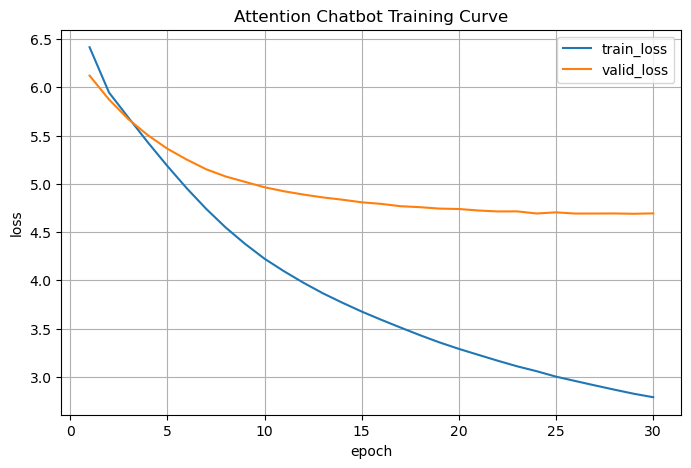

,epoch,train_loss,valid_loss,lr
0,1,6.414815,6.120269,0.0003
1,2,5.945268,5.873045,0.0003
2,3,5.684857,5.668284,0.0003
3,4,5.428438,5.503011,0.0003
4,5,5.184281,5.363567,0.0003
5,6,4.953167,5.250518,0.0003
6,7,4.739829,5.150245,0.0003
7,8,4.546964,5.075353,0.0003
8,9,4.376997,5.019584,0.0003
9,10,4.223383,4.963727,0.0003


In [13]:
# matplotlib.pyplot import
import matplotlib.pyplot as plt

# 학습 결과를 그래프로 보자
plt.figure(figsize=(8, 5))
# train loss 선
plt.plot(history["epoch"], history["train_loss"], label="train_loss")
# valid loss 선
plt.plot(history["epoch"], history["valid_loss"], label="valid_loss")
# x축 이름
plt.xlabel("epoch")
# y축 이름
plt.ylabel("loss")
# 제목
plt.title("Attention Chatbot Training Curve")
# 범례 표시
plt.legend()
# 격자 표시
plt.grid(True)
# 그래프 출력
plt.show()

# 학습 기록을 표로 만든다
history_df = pd.DataFrame(history)
# 표 출력
display(history_df)

train loss는 계속 내려가는데  

validation loss는 수렴된것 같다  

학습을 더 해도 의미 없을것 같다고 판단된다  

validation이 더 소중하니까  

검증 성능이 좋았던 모델 저장해놨으니까 이제 불러와서  

답변할때 필요한 함수를 작성한다  

In [19]:
from difflib import SequenceMatcher

# 저장된 best 모델을 불러온다
checkpoint = torch.load(SAVE_PATH, map_location=device)
# 모델 가중치 적용
model.load_state_dict(checkpoint["model_state_dict"])
# 모델 평가 모드
model.eval()

# 토큰 번호 목록을 사람이 읽는 문장으로 바꾸는 함수
def ids_to_sentence(ids):
    # 특수 토큰은 빼고 일반 토큰만 남긴다
    ids = [
        int(i) for i in ids
        if int(i) not in [PAD_ID, BOS_ID, EOS_ID]
    ]
    # 토크나이저로 문장 복원
    return tokenizer.decode(ids)

# 이미 만든 토큰이 너무 반복되지 않도록 점수를 조정하는 함수
def apply_repetition_penalty(logits, generated_ids, penalty=1.25):
    # 이미 사용한 토큰 모음
    used = set(int(x) for x in generated_ids)

    # 사용한 토큰을 하나씩 본다
    for token_id in used:
        # 특수 토큰은 건드리지 않는다
        if token_id in [PAD_ID, BOS_ID, UNK_ID]:
            continue
        # 점수가 양수면 나눠서 낮춘다
        if logits[0, token_id] > 0:
            logits[0, token_id] /= penalty
        # 점수가 음수면 곱해서 더 낮춘다
        else:
            logits[0, token_id] *= penalty

    # 조정된 logits 반환
    return logits

# 같은 n-gram 반복을 막는 함수
def block_repeated_ngram(logits, generated_ids, ngram_size=3):
    # n-gram을 만들 길이가 안 되면 통과
    if len(generated_ids) < ngram_size - 1:
        return logits

    # 현재 끝부분 prefix
    prefix = tuple(generated_ids[-(ngram_size - 1):])
    # 금지할 다음 토큰 목록
    banned = []

    # 이전 n-gram들을 확인
    for i in range(len(generated_ids) - ngram_size + 1):
        # n-gram 하나 추출
        ngram = tuple(generated_ids[i:i + ngram_size])
        # prefix가 같으면 마지막 토큰을 금지
        if ngram[:-1] == prefix:
            banned.append(ngram[-1])

    # 금지 토큰이 있으면 점수를 -inf로 만든다
    if banned:
        logits[0, banned] = -float("inf")

    # 수정된 logits 반환
    return logits

# 학습된 Attention Transformer로 답변을 생성하는 함수
@torch.no_grad()
def generate_answer(question, max_len=MAX_LEN):
    # 모델 평가 모드
    model.eval()
    # 입력 문장 전처리
    question = preprocess_sentence(question)
    # 질문을 토큰으로 바꾸고 패딩
    src_ids = pad_to_len(encode_sentence(question, max_len=max_len), max_len=max_len)
    # 질문 텐서 생성
    src = torch.tensor([src_ids], dtype=torch.long, device=device)
    # 답변은 BOS부터 시작
    generated = torch.tensor([[BOS_ID]], dtype=torch.long, device=device)

    # 최대 길이까지 한 토큰씩 생성
    for step in range(max_len - 1):
        # 현재까지 만든 답변을 넣어 다음 토큰 점수를 얻는다
        logits = model(src, generated)
        # 마지막 위치의 vocab 점수만 사용한다
        next_logits = logits[:, -1, :].clone()

        # 나오면 곤란한 특수 토큰 차단
        next_logits[:, [PAD_ID, BOS_ID, UNK_ID]] = -float("inf")
        # 너무 짧게 끝나지 않게 초반 EOS 차단
        if step < 2:
            next_logits[:, EOS_ID] = -float("inf")

        # 지금까지 생성한 토큰 리스트
        generated_list = generated[0].tolist()
        # 반복 토큰 점수 낮추기
        next_logits = apply_repetition_penalty(next_logits, generated_list, penalty=1.25)
        # 반복 n-gram 차단
        next_logits = block_repeated_ngram(next_logits, generated_list, ngram_size=3)

        # 가장 점수가 높은 토큰 선택
        next_id = int(torch.argmax(next_logits, dim=-1).item())
        # EOS가 나오면 생성 종료
        if next_id == EOS_ID:
            break
        # 다음 토큰 텐서 생성
        next_token = torch.tensor([[next_id]], dtype=torch.long, device=device)
        # 생성 결과 뒤에 붙인다
        generated = torch.cat([generated, next_token], dim=1)

    # 토큰을 문장으로 바꿔 반환
    return ids_to_sentence(generated[0].tolist())

# 생성된 답변이 너무 짧거나 반복되는지 검사하는 함수
def is_low_quality_answer(answer):
    # 문자열로 변환하고 공백 제거
    answer = str(answer).strip()
    # 공백 기준 토큰화
    tokens = answer.split()

    # 너무 짧으면 품질 낮음
    if len(answer) < 2:
        return True
    # 길이가 충분할 때 반복 비율 검사
    if len(tokens) >= 8:
        # 토큰 빈도 계산
        token_counts = Counter(tokens)
        # 가장 흔한 토큰 비율
        most_common_ratio = max(token_counts.values()) / len(tokens)
        # 고유 토큰 비율
        unique_ratio = len(set(tokens)) / len(tokens)
        # 반복이 심하면 품질 낮음
        if most_common_ratio >= 0.35 or unique_ratio <= 0.45:
            return True
    # 짧은 문자열 반복 패턴 검사
    if re.search(r"(.{1,6})\s*(\1\s*){3,}", answer):
        return True

    # 괜찮으면 False
    return False

# 가장 비슷한 학습 질문을 찾는 함수
def retrieve_answer(question):
    # 입력 질문도 학습 데이터와 같은 방식으로 정리한다
    processed_question = preprocess_sentence(question)

    # 아직 후보를 찾지 않았으므로 가장 낮은 값으로 시작한다
    best_score = -1.0

    # 가장 비슷한 질문의 답변을 담을 공간
    best_answer = ""

    # 실제로 어떤 질문이 선택되었는지도 저장한다
    best_question = ""

    # 학습 데이터의 질문과 답변을 하나씩 확인한다
    for candidate_question, candidate_answer in zip(
        clean_df["Q"],
        clean_df["A"]
    ):
        # 두 질문의 글자 배열이 얼마나 비슷한지 계산한다
        score = SequenceMatcher(
            None,
            processed_question,
            candidate_question
        ).ratio()

        # 지금까지 찾은 값보다 더 비슷하면 주인공 교체
        if score > best_score:
            best_score = score
            best_question = candidate_question
            best_answer = candidate_answer

    # 검색 답변, 매칭 질문, 문자열 유사도를 반환한다
    return best_answer, best_question, best_score


# Attention 답변과 검색 답변 중 최종 답변을 고르는 함수
def answer_question(question, use_retrieval_fallback=True):
    # Attention Transformer가 직접 답변을 만든다
    attention_answer = generate_answer(question)

    # 학습 데이터에서 글자가 가장 비슷한 질문도 찾는다
    retrieval_answer, matched_question, retrieval_similarity = (
        retrieve_answer(question)
    )

    # 처음에는 Attention 답변을 사용할 준비를 한다
    use_fallback = False

    # 검색 답변을 안전망으로 사용할지 확인한다
    if use_retrieval_fallback:

        # Attention 답변이 너무 짧거나 반복되면 안전망 가동
        if is_low_quality_answer(attention_answer):
            use_fallback = True

        # 입력 질문과 거의 같은 질문이 학습 데이터에 있어도 안전망 가동
        elif retrieval_similarity >= 0.92:
            use_fallback = True

    # 안전망이 켜지면 검색 답변을 사용한다
    if use_fallback:
        final_answer = retrieval_answer
        source = "retrieval_fallback"

    # 그렇지 않으면 Attention 모델의 답변을 사용한다
    else:
        final_answer = attention_answer
        source = "attention_transformer"

    # 여러 결과를 딕셔너리로 묶어서 반환한다
    return {
        "question": question,
        "answer": final_answer,
        "source": source,
        "attention_answer": attention_answer,
        "matched_question": matched_question,

        # 이 값은 답변 정확도가 아니라 질문 문자열 유사도다
        "retrieval_similarity": round(
            float(retrieval_similarity),
            4
        ),
    }


# 질문 하나를 넣고 결과를 보기 좋게 출력하는 함수
def chat(question):
    # 챗봇에게 질문하고 결과를 받는다
    result = answer_question(question)

    # 사용자가 입력한 질문
    print(f"Q: {result['question']}")

    # 최종 선택된 답변
    print(f"A: {result['answer']}")

    # 답변이 어느 방식으로 만들어졌는지 표시
    print(f"source: {result['source']}")

    # 검색 과정에서 가장 비슷했던 학습 질문
    print(f"matched question: {result['matched_question']}")

    # 답변 점수가 아니라 질문 글자 유사도라는 점을 분명히 표시
    print(
        "retrieval similarity: "
        f"{result['retrieval_similarity']}"
    )

    # 결과 사이에 작은 울타리를 세운다
    print("-" * 60)

    # 표로 만들 수 있도록 결과도 반환한다
    return result

질문 예시 작성 하고 답변을 출력해보자  

In [22]:
# 제출용 예시 질문 목록
sample_questions = [
    # 예시 문장
    "트랜스포머 모델 학습이 너무 어렵다",
    "오늘 일찍 일어났더니 피곤하다.",
    "너는 밥은 먹고 다니냐?",
    "아이펠 수업에 대해 어떻게 생각해?",
    "제주도에 어떤 음식이 맛있어?",
    "너는 누구야?",
    "주말에 하면 가장 재미있는 일이 뭘까?",
    "공부는 어떻게 하나요?",
    "챗 지피티를  알고 있나?",
    "사랑과 우정 중 뭐가 더 중요한가?",
]

# 질문별 답변 결과를 담을 빈 리스트
sample_answer_results = []

# 질문을 하나씩 챗봇에게 전달한다
for question in sample_questions:
    # chat() 함수의 결과를 리스트에 저장한다
    result = chat(question)
    sample_answer_results.append(result)

# 결과 리스트를 표 형태의 DataFrame으로 만든다
sample_answer_df = pd.DataFrame(sample_answer_results)

# 제출에 필요한 열만 골라서 보여준다
display(
    sample_answer_df[
        [
            "question",
            "answer",
            "source",
            "matched_question",
            "retrieval_similarity",
        ]
    ]
)

Q: 트랜스포머 모델 학습이 너무 어렵다
A: 앞머리로 가리세요 .
source: attention_transformer
matched question: 스트레스 참기 어렵다
retrieval similarity: 0.4667
------------------------------------------------------------
Q: 오늘 일찍 일어났더니 피곤하다.
A: 충전하고 만나요 .
source: attention_transformer
matched question: 자고 일어났더니 하루 다갔어 .
retrieval similarity: 0.6286
------------------------------------------------------------
Q: 너는 밥은 먹고 다니냐?
A: 잘 찾아보세요 .
source: attention_transformer
matched question: 엄마 밥 먹고 싶다
retrieval similarity: 0.5833
------------------------------------------------------------
Q: 아이펠 수업에 대해 어떻게 생각해?
A: 요즘 뜨는 거 같아요 .
source: attention_transformer
matched question: 랜선 연애 어떻게 생각해 ?
retrieval similarity: 0.6286
------------------------------------------------------------
Q: 제주도에 어떤 음식이 맛있어?
A: 맛있게 먹으면 0칼로리 !
source: attention_transformer
matched question: 너도 고민 있어 ?
retrieval similarity: 0.5185
------------------------------------------------------------
Q: 너는 누구야?
A: 저는 마음을 이어주는 위로봇입니다 .
source: attention_transfor

,question,answer,source,matched_question,retrieval_similarity
0,트랜스포머 모델 학습이 너무 어렵다,앞머리로 가리세요 .,attention_transformer,스트레스 참기 어렵다,0.4667
1,오늘 일찍 일어났더니 피곤하다.,충전하고 만나요 .,attention_transformer,자고 일어났더니 하루 다갔어 .,0.6286
2,너는 밥은 먹고 다니냐?,잘 찾아보세요 .,attention_transformer,엄마 밥 먹고 싶다,0.5833
3,아이펠 수업에 대해 어떻게 생각해?,요즘 뜨는 거 같아요 .,attention_transformer,랜선 연애 어떻게 생각해 ?,0.6286
4,제주도에 어떤 음식이 맛있어?,맛있게 먹으면 0칼로리 !,attention_transformer,너도 고민 있어 ?,0.5185
5,너는 누구야?,저는 마음을 이어주는 위로봇입니다 .,attention_transformer,너 누구 ?,0.8571
6,주말에 하면 가장 재미있는 일이 뭘까?,영화를 찾아보세요 .,attention_transformer,이런 가사 보내는 이유가 뭘까 ?,0.5500
7,공부는 어떻게 하나요?,우선 꾸준히 연락하고 잘해줘보세요 .,attention_transformer,썸 어떻게 타 ?,0.6364
8,챗 지피티를 알고 있나?,그 사람도 그럴 거예요 .,attention_transformer,다 알고 있을까 ?,0.5833
9,사랑과 우정 중 뭐가 더 중요한가?,회사와 자신에 대해서 더 공부해서 자신감을 가져보세요 .,attention_transformer,사랑할 때도 용기가 필요하지 ?,0.4865


뭔.....가...?  

답변이 이상하다  

뭔가 대답이 맞을때도 있고 기분 나쁘게 엉뚱한 대답을 하기도 한다  

문장을 길게 할때의 질문이 더 매칭 안되는 대답을 하는것 같은데  

생각해보니 학습 데이터가 부족해서 그런것 같다  

질문과 매칭 질문이 아예 매칭이 안되는 경우가 많다  

첫번째는 트랜스포머 학습을 물어봤는데 트랜스포머를 모르니 "어렵다" 에 더 많은 가중치가 들어가나보다  

두번째도 일어나다에 더 가중치가 들어가는것 같고  

세번째는 밥 에 더 가중치가 들어가는것 같다  

In [23]:
# source별 개수를 계산
source_counts = sample_answer_df["source"].value_counts().to_dict()

# 평가 기준 체크리스트
checklist = pd.DataFrame([
    {
        "평가 항목": "전처리/증강",
        "코드 근거": "preprocess_sentence(), clean_chatbot_dataframe(), build_augmented_dataset()",
        "결과": f"원본 정제 {len(clean_df):,}개, 학습 데이터 {len(train_df):,}개 구성, valid leakage 방지",
    },
    {
        "평가 항목": "Attention 모델 학습",
        "코드 근거": "AttentionChatbotTransformer, nn.Transformer 내부 Multi-Head Attention, train_one_epoch(), evaluate()",
        "결과": f"best valid loss = {best_valid_loss:.4f}, min_delta={HYPERPARAMS['min_delta']}",
    },
    {
        "평가 항목": "과적합 방지",
        "코드 근거": "train/valid split, dropout, label_smoothing, weight_decay, grad_clip, scheduler, early stopping",
        "결과": f"early_stopping_patience={HYPERPARAMS['early_stopping_patience']}, dropout={HYPERPARAMS['dropout']}",
    },
    {
        "평가 항목": "챗봇 답변 사례",
        "코드 근거": "generate_answer(), answer_question(), chat(), sample_questions",
        "결과": f"예시 질문별 답변 출력 완료, source 분포={source_counts}",
    },
])

# 체크리스트 출력
display(checklist)

,평가 항목,코드 근거,결과
0,전처리/증강,"preprocess_sentence(), clean_chatbot_dataframe...","원본 정제 11,739개, 학습 데이터 30,000개 구성, valid leakag..."
1,Attention 모델 학습,"AttentionChatbotTransformer, nn.Transformer 내부...","best valid loss = 4.6889, min_delta=0.001"
2,과적합 방지,"train/valid split, dropout, label_smoothing, w...","early_stopping_patience=6, dropout=0.2"
3,챗봇 답변 사례,"generate_answer(), answer_question(), chat(), ...","예시 질문별 답변 출력 완료, source 분포={'attention_transfo..."


# 전체 코드 요약  

이번 프로젝트에서는 질문과 답변으로 구성된 대화 데이터를 이용하여 Attention 기반 Transformer 챗봇을 만들었다.  

먼저 필요한 라이브러리를 설치하고 랜덤 시드를 고정한 뒤, GPU 사용 가능 여부에 따라 학습 장치를 설정하였다.  

이후 ChatbotData.csv 파일을 여러 경로에서 탐색하고, 로컬에 파일이 없으면 인터넷에서 내려받도록 구성하였다.  

데이터의 질문과 답변 컬럼 이름이 서로 달라도 사용할 수 있도록 최종 컬럼을 Q와 A로 통일하였다.  

불러온 문장에서는 HTML 태그, URL, 불필요한 특수문자와 반복 공백을 제거하였다.  

너무 짧거나 긴 문장과 중복된 질문·답변도 제거하여 학습에 적합한 데이터만 남겼다.  

정제된 데이터는 학습 데이터와 검증 데이터로 분리하였으며, 학습 데이터에만 동의어 교체, 문장부호 변경, 말투 변화 등의 증강을 적용하여 약 3만 개의 질문·답변 쌍을 구성하였다.  

검증 데이터에는 증강을 적용하지 않아 데이터 누수를 방지하였다.  

정리된 문장은 SentencePiece의 BPE 토크나이저를 이용하여 작은 토큰으로 나눈 뒤 숫자 ID로 변환하였다.  

각 문장에는 시작을 의미하는 BOS 토큰과 끝을 의미하는 EOS 토큰을 추가하였고, 문장의 길이는 PAD 토큰을 사용하여 동일하게 맞추었다.  

챗봇 모델은 PyTorch의 Transformer 구조를 사용하였다.  

질문은 Encoder로 전달되고, 답변은 Decoder에서 한 토큰씩 생성된다.  

Transformer 내부의 Multi-Head Attention은 질문 속 단어들의 관계를 여러 관점에서 분석하며, Decoder는 Encoder가 만든 질문 정보를 참고하여 다음 답변 토큰을 예측한다.  

Transformer는 단어를 순서대로 처리하지 않으므로 Positional Encoding을 추가하여 문장 속 단어의 위치 정보도 함께 전달하였다.  

모델 학습에서는 답변 문장을 한 칸씩 이동하여 이전 토큰을 보고 다음 토큰을 맞히도록 구성하였다.  

Cross Entropy Loss를 사용하여 예측과 정답의 차이를 계산하고, 역전파와 optimizer를 통해 모델의 가중치를 수정하였다.  

과적합을 줄이기 위해 train/validation 분리, Dropout, Weight Decay, Label Smoothing, Gradient Clipping, Learning-rate Scheduler, Early Stopping을 적용하였다.  

검증 손실이 가장 낮았던 모델은 best_attention_chatbot.pt 파일로 저장하였다.  

학습이 끝난 후에는 저장된 최적 모델을 불러와 사용자의 질문에 답변을 생성하였다.  

모델은 BOS 토큰에서 시작하여 다음 토큰을 하나씩 예측하고 EOS 토큰이 나오면 생성을 종료한다.  

답변에서 같은 단어나 문장이 반복되는 현상을 줄이기 위해 repetition penalty와 repeated n-gram blocking도 적용하였다.  

추가로 생성 답변이 지나치게 짧거나 반복적인 경우를 보완하기 위해 검색 기반 fallback 기능을 사용하였다.  

SequenceMatcher로 사용자의 질문과 학습 데이터의 질문을 비교한 뒤 가장 문자열이 비슷한 질문과 답변을 찾는다.  

이때 출력되는 retrieval_similarity는 챗봇 답변의 정확도가 아니라 입력 질문과 저장된 질문의 문자열 유사도를 의미한다.  

최종적으로 Attention Transformer가 만든 답변과 검색 기반 답변 중 조건에 맞는 답변을 선택하며, source 값을 통해 답변이 Attention 모델에서 생성되었는지 검색 기능에서 가져온 것인지 확인할 수 있다.  

마지막에는 여러 예시 질문을 입력하여 질문, 최종 답변, 답변 출처, 가장 비슷한 학습 질문, 문자열 유사도를 표로 확인하였다.  

코드 실행시 만들어진 모델과 결과물, 학습데이터는 용량이 많아 github에 올라갈때 자꾸 오류가 나서 삭제하였다  

# 회고  

이번 프로젝트를 진행하면서 챗봇은 단순히 질문과 답변 데이터를 모델에 넣는 것만으로 완성되는 것이 아니라는 점을 알게 되었다.  

데이터 정제, 데이터 증강, 토큰화, 모델 설계, 학습, 검증, 답변 생성까지 여러 과정이 서로 연결되어야 하나의 챗봇이 작동한다는 것을 확인할 수 있었다.  

특히 Transformer에서는 Attention을 이용하여 질문 속 단어들이 서로 어떤 관계를 가지는지 학습한다는 점이 흥미로웠다.  

RNN처럼 문장을 한 단어씩 순서대로 읽지 않기 때문에 Positional Encoding을 이용해 단어의 위치 정보를 따로 넣어야 한다는 점도 새롭게 알게 되었다.  

Encoder는 질문을 이해하고 Decoder는 그 정보를 참고하여 답변을 한 토큰씩 생성한다는 전체 구조도 그냥 책과 노드로 학습할때보다 구체적으로 이해할 수 있었다.  

학습 데이터만 많이 만드는 것이 항상 좋은 것은 아니라는 점도 배웠다.  

검증 데이터까지 증강하면 비슷한 문장이 학습 데이터와 검증 데이터에 함께 포함될 수 있고, 이 경우 실제 성능보다 결과가 좋게 보일 수 있다.   

이번 코드에서는 학습 데이터에만 증강을 적용하여 데이터 누수를 막았다는 점이 중요하다고 생각한다.  

또한 모델이 학습 데이터의 문장을 지나치게 외우는 것을 막기 위해 Dropout, Label Smoothing, Weight Decay, Gradient Clipping, Scheduler, Early Stopping 등 여러 방법을 함께 적용했다.  

학습 그래프에서 train loss뿐 아니라 validation loss도 함께 확인해야 실제로 모델이 잘 학습되는지 판단할 수 있다는 점도 이해하게 되었다.  

실제 챗봇 결과를 확인했을 때 자연스러운 답변이 나오는 경우도 있었지만, 질문과 맞지 않는 엉뚱한 답변이 생성되는 경우도 있었다.  

이를 통해 loss가 감소했다고 해서 모든 답변이 자연스럽고 정확해지는 것은 아니라는 점을 알게 되었다.  

챗봇의 품질을 높이려면 데이터의 양뿐 아니라 질문과 답변의 다양성, 데이터 품질, 모델 크기, 학습 방법, 답변 생성 방식도 함께 개선해야 할 것 같다.  

처음에는 similarity 값이 챗봇 답변의 정확도를 나타내는 것으로 생각했지만, 코드를 확인한 결과 SequenceMatcher가 입력 질문과 학습 질문의 글자 배열을 비교한 값이라는 것을 알게 되었다.  

따라서 유사도 값이 높더라도 생성된 답변이 반드시 적절하다는 뜻은 아니었다.  

문자열 유사도와 의미적 유사도, 답변 품질 평가는 서로 다른 개념이라는 점을 배웠다.  

이번 프로젝트를 통해 Attention 기반 챗봇의 전체 흐름을 직접 연결해 볼 수 있었다.  

아직 답변의 자연스러움과 정확성에는 개선할 부분이 있지만, 데이터가 토큰으로 변환되고 Transformer가 이를 학습하여 새로운 답변을 만들어 내는 과정을 확인한 것이 의미 있었다.  

이후에는 문장의 의미를 비교할 수 있는 임베딩 기반 유사도 평가와 더 다양한 학습 데이터를 적용하여 챗봇의 답변 품질을 개선해 보고 싶다.  